# Visualize Wall BT Trees

Load an episode JSON produced and render each generated behavior tree as a directed graph.

In [22]:
from pathlib import Path
import json
import networkx as nx
import matplotlib.pyplot as plt

episode_path = Path("../results/wall_bt_2026-04-13_16-10-28/Qwen/Qwen2.5-3B-Instruct/episode_0.json")
episode_data = json.loads(episode_path.read_text(encoding="utf-8"))
behavior_trees = episode_data.get("behavior_trees", [])

print(f"Loaded {len(behavior_trees)} behavior tree(s) from: {episode_path}")

Loaded 1 behavior tree(s) from: ..\results\wall_bt_2026-04-13_16-10-28\Qwen\Qwen2.5-3B-Instruct\episode_0.json


In [23]:
def _strip_json_fences(text: str) -> str:
    text = (text or "").strip()
    if text.startswith("```"):
        lines = text.splitlines()
        if lines and lines[0].strip().startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]
        text = "\n".join(lines).strip()
    return text

def _node_label(node: dict) -> str:
    node_type = node.get("type", "?")
    if node_type == "condition":
        observation = node.get("observation", "?")
        expected = node.get("expected", True)
        condition_text = f"{observation} == {expected}"
        return f"condition\n{condition_text}"
    if node_type == "action":
        call = node.get("call", {})
        tool_name = call.get("tool_name", "?")
        args = call.get("arguments", {})
        if args:
            args_text = "\n".join(f"{k}={v}" for k, v in args.items())
            return f"action\n{tool_name}\n{args_text}"
        return f"action\n{tool_name}"
    return node_type

def _add_bt_nodes(graph: nx.DiGraph, node: dict, parent_id: str | None = None, idx: list[int] | None = None) -> None:
    if idx is None:
        idx = [0]

    node_id = f"n{idx[0]}"
    idx[0] += 1
    graph.add_node(node_id, label=_node_label(node))

    if parent_id is not None:
        graph.add_edge(parent_id, node_id)

    for child in node.get("children", []):
        _add_bt_nodes(graph, child, parent_id=node_id, idx=idx)

def _tree_layout_top_down(graph: nx.DiGraph, root: str) -> dict[str, tuple[float, float]]:
    levels: dict[int, list[str]] = {}

    def _walk(node_id: str, depth: int) -> None:
        levels.setdefault(depth, []).append(node_id)
        for child_id in graph.successors(node_id):
            _walk(child_id, depth + 1)

    _walk(root, 0)

    pos: dict[str, tuple[float, float]] = {}
    for depth, nodes in levels.items():
        width = len(nodes)
        for i, node_id in enumerate(nodes):
            x = (i + 1) / (width + 1)
            y = -(depth * 1.5)
            pos[node_id] = (x, y)

    return pos

def render_behavior_tree(bt_payload: dict, title: str = "Behavior Tree") -> None:
    graph = nx.DiGraph()
    root = bt_payload.get("root")
    if not isinstance(root, dict):
        raise ValueError("BT payload must contain a dict root node")

    _add_bt_nodes(graph, root)
    labels = nx.get_node_attributes(graph, "label")

    root_node = "n0"
    pos = _tree_layout_top_down(graph, root_node)

    plt.figure(figsize=(14, 9))
    nx.draw(
        graph,
        pos,
        with_labels=False,
        arrows=True,
        node_size=5000,
        node_color="#DDEEFF",
        edge_color="#666666",
    )
    nx.draw_networkx_labels(
        graph,
        pos,
        labels=labels,
        font_size=11,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 0.3},
    )
    plt.title(title)
    plt.axis("off")
    plt.show()

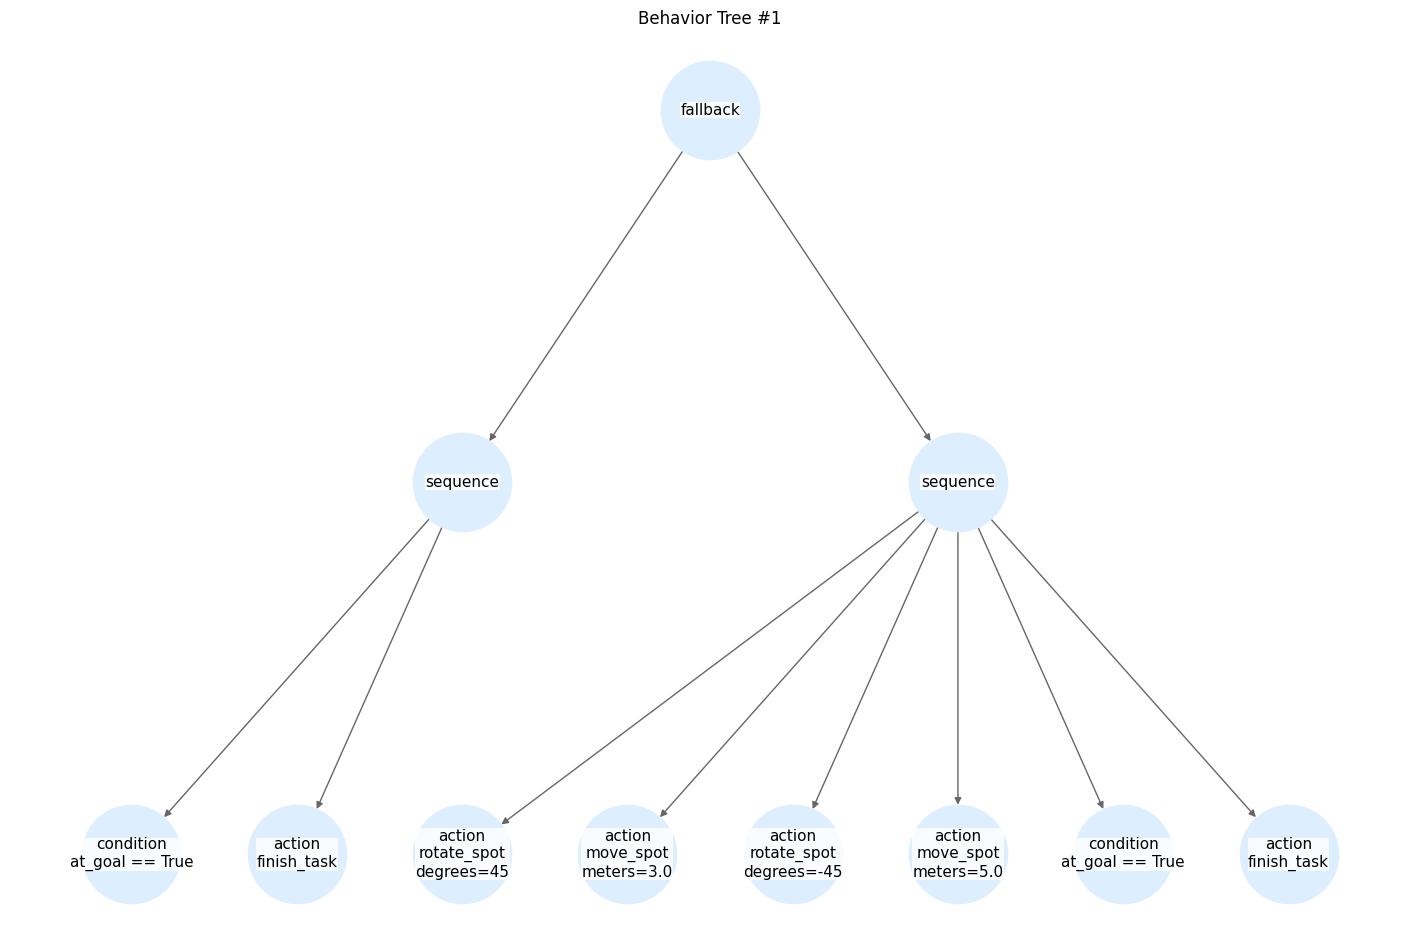

In [24]:
for entry in behavior_trees:
    bt_index = entry.get("bt_index")
    raw_output = entry.get("llm_output", "")

    try:
        bt_payload = json.loads(_strip_json_fences(raw_output))
    except Exception as error:
        print(f"Skipping bt_index={bt_index}: could not parse llm_output -> {error}")
        continue

    render_behavior_tree(bt_payload, title=f"Behavior Tree #{bt_index}")